In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline

# 한글 폰트
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid")

### [B] 개인 단위 분석 기준

- 분석 단위: 개인(person)
- 정의:
  - viewed = 오퍼를 한 번이라도 조회한 경험
  - completed = 오퍼를 한 번이라도 완료한 경험
- 지표:
  - Viewed 경험이 있는 고객 중,
    완료 경험이 전혀 없는 고객 비율
- 목적:
  - 가입 시점에 따른 고객의 전반적 오퍼 이용 경험 수준 비교

In [2]:
# 데이터 로드
profile = pd.read_json("../data/raw/profile.json", orient="records", lines=True)
transcript = pd.read_json("../data/raw/transcript.json", orient="records", lines=True)

# 가입일 datetime 변환
profile['became_member_on'] = pd.to_datetime(
    profile['became_member_on'].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

profile['join_year'] = profile['became_member_on'].dt.year

# transcript에서 viewed / completed 요약
event_summary = (
    transcript
    .pivot_table(
        index='person',
        columns='event',
        values='time',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

event_summary['viewed'] = event_summary.get('offer viewed', 0) > 0
event_summary['completed'] = event_summary.get('offer completed', 0) > 0

# 최종 분석 테이블
df = (
    profile[['id', 'join_year']]
    .merge(event_summary[['person', 'viewed', 'completed']],
           left_on='id', right_on='person', how='inner')
)

display(df.head())

,id,join_year,person,viewed,completed
0,68be06ca386d4c31939f3a4f0e3dd783,2017,68be06ca386d4c31939f3a4f0e3dd783,True,True
1,0610b486422d4921ae7d2bf64640c50b,2017,0610b486422d4921ae7d2bf64640c50b,False,True
2,38fe809add3b4fcf9315a9694bb96ff5,2018,38fe809add3b4fcf9315a9694bb96ff5,True,False
3,78afa995795e4d85b5d9ceeca43f5fef,2017,78afa995795e4d85b5d9ceeca43f5fef,True,True
4,a03223e636434f42ac4c3df47e8bac43,2017,a03223e636434f42ac4c3df47e8bac43,True,False


In [3]:
# 가입년도별 미완료 고객 비율 계산
cohort_person_drop = (
    df[df['viewed'] == True]
    .groupby('join_year')['completed']
    .mean()
    .rsub(1)
    .mul(100)
    .round(1)
    .reset_index(name='no_completion_rate')
    .sort_values('join_year')
)

display(cohort_person_drop)

,join_year,no_completion_rate
0,2013,15.1
1,2014,17.0
2,2015,11.9
3,2016,10.3
4,2017,25.7
5,2018,42.2


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/li

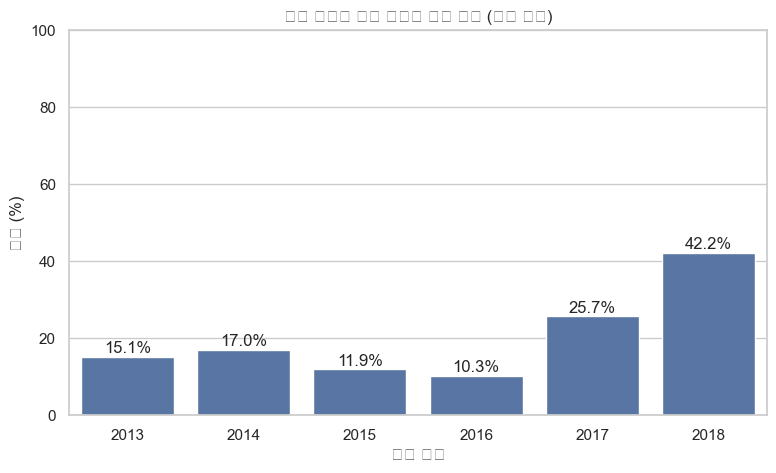

In [4]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=cohort_person_drop,
    x='join_year',
    y='no_completion_rate'
)

plt.title('가입 연도별 오퍼 미완료 고객 비율 (개인 단위)')
plt.xlabel('가입 연도')
plt.ylabel('비율 (%)')
plt.ylim(0, 100)

for i, row in cohort_person_drop.iterrows():
    plt.text(i, row['no_completion_rate'] + 1,
             f"{row['no_completion_rate']}%",
             ha='center')

plt.show()

가입 연도별로
오퍼를 ‘한 번이라도 본 고객’ 중
단 한 번도 완료하지 못한 고객의 비율을 보여주는 그래프임.

개인 단위 기준으로 분석한 결과,
최근 가입 고객일수록 오퍼를 조회한 경험은 있으나
완료 경험이 전혀 없는 고객 비율이 높게 나타났다.

이는 가입 시점에 따른 서비스 이용 경험 수준 차이가
오퍼 활용 여부 전반에 영향을 미칠 가능성을 시사한다.

---
### [A] 오퍼 단위 퍼널 이탈 분석 기준 (메인)

- 분석 단위: 고객 × 오퍼 (person × offer)
- 이탈률 정의:
  - Viewed가 발생한 오퍼 중, Completed가 발생하지 않은 오퍼의 비율
- 집계 기준: 가입 연도(join_year)
- 목적: ‘Viewed → Completed’ 병목이 가입 시점에 따라 구조적으로 달라지는지 확인

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

profile = pd.read_json("../data/raw/profile.json", orient="records", lines=True)
transcript = pd.read_json("../data/raw/transcript.json", orient="records", lines=True)

# 가입연도 만들기
profile['became_member_on'] = pd.to_datetime(
    profile['became_member_on'].astype(str),
    format="%Y%m%d",
    errors="coerce"
)
profile['join_year'] = profile['became_member_on'].dt.year

# transcript에서 오퍼 이벤트만
offer_events = transcript[transcript['event'].isin(['offer received','offer viewed','offer completed'])].copy()
offer_events.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [6]:
# A-2. offer_id 추출
def extract_offer_id(v):
    if isinstance(v, dict):
        return v.get('offer id') or v.get('offer_id')
    return None

offer_events['offer_id'] = offer_events['value'].apply(extract_offer_id)

# 확인
offer_events[['person','event','offer_id','time']].head()

,person,event,offer_id,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,0


In [7]:
# A-3. person + offer 퍼널 테이블 만들기

person_offer = (
    offer_events
    .pivot_table(
        index=['person', 'offer_id'],
        columns='event',
        values='time',
        aggfunc='min'
    )
    .reset_index()
)

# 단계 boolean
person_offer['received']  = person_offer['offer received'].notna()
person_offer['viewed']    = person_offer['offer viewed'].notna()
person_offer['completed'] = person_offer['offer completed'].notna()

person_offer[['person','offer_id','received','viewed','completed']].head()

event,person,offer_id,received,viewed,completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,True,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,True,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,True,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,True,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,True,True,True


In [8]:
#정합체크
print("행 수(person×offer):", len(person_offer))
print(person_offer[['received','viewed','completed']].mean().round(3))

행 수(person×offer): 63288
event
received     1.000
viewed       0.776
completed    0.458
dtype: float64


---
### 노트북 03 파일 종료 8단계에서 시각화 안되었던 분석 다시 실행 중 : 분석 기본 단위 다시 점검
	•	단위: person × offer
	•	대상: offer received가 발생한 모든 오퍼
	•	퍼널:
Received → Viewed → Completed
	•	이탈 정의(A안):
👉 Viewed는 했으나 Completed로 이어지지 않은 경우

즉,

“가입 연도별 고객들이
조회(Viewed)까지는 한 오퍼 중,
완료(Completed)까지 못 간 오퍼 비율”

In [9]:
# 가입시점 (코호트) 붙이기
# profile에서 join_year 가져오기
profile = pd.read_json(
    "../data/raw/profile.json",
    orient="records",
    lines=True
)

profile['became_member_on'] = pd.to_datetime(
    profile['became_member_on'].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

profile['join_year'] = profile['became_member_on'].dt.year

profile = profile[['id', 'join_year']]

In [10]:
#person_offer에 join_year merge

person_offer = person_offer.merge(
    profile,
    left_on='person',
    right_on='id',
    how='left'
)

In [11]:
person_offer[['person', 'offer_id', 'join_year', 'viewed', 'completed']].head()

,person,offer_id,join_year,viewed,completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,2017,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,2017,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,2017,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,2017,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,2017,True,True


In [12]:
#가입연도별 viewed -> completed 이탈률 계산

cohort_drop_A = (
    person_offer
    [person_offer['viewed'] == True]          # Viewed 기준
    .groupby('join_year')['completed']
    .mean()
    .rsub(1)                                  # 1 - completion rate
    .mul(100)
    .round(1)
    .reset_index(name='viewed_to_completed_drop_rate')
    .sort_values('join_year')
)

display(cohort_drop_A)

,join_year,viewed_to_completed_drop_rate
0,2013,48.2
1,2014,48.9
2,2015,38.9
3,2016,35.6
4,2017,51.1
5,2018,66.6


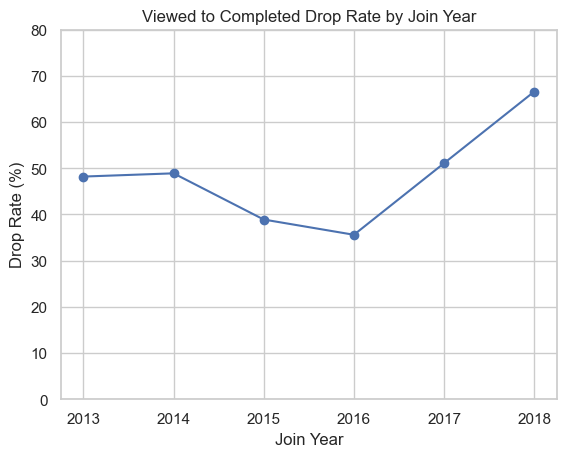

In [13]:
plt.figure()

plt.plot(
    cohort_drop_A['join_year'],
    cohort_drop_A['viewed_to_completed_drop_rate'],
    marker='o'
)

plt.title('Viewed to Completed Drop Rate by Join Year')
plt.xlabel('Join Year')
plt.ylabel('Drop Rate (%)')
plt.ylim(0, 80)

plt.show()

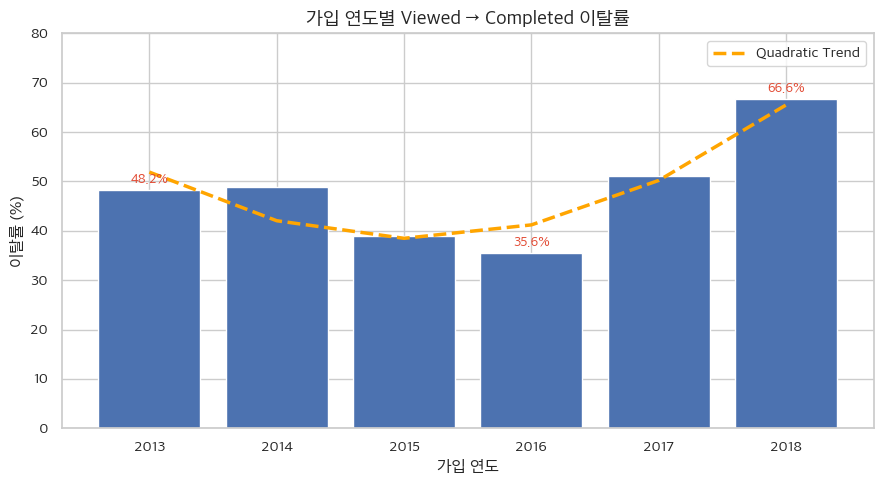

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 폰트 고정
mpl.rcParams['font.family'] = 'Apple SD Gothic Neo'
mpl.rcParams['axes.unicode_minus'] = False

x = cohort_drop_A['join_year']
y = cohort_drop_A['viewed_to_completed_drop_rate']

plt.figure(figsize=(9, 5))

# 1️⃣ 막대그래프
bars = plt.bar(x, y, color='#4C72B0')  # 기존 파란색

# 2️⃣ 추세선 (선형 회귀)
z = np.polyfit(x, y, 2)   # 2차 곡선
p = np.poly1d(z)

plt.plot(
    x,
    p(x),
    color='orange',
    linewidth=2.5,
    linestyle='--',
    label='Quadratic Trend'
)

# 3️⃣ 제목 / 축
plt.title('가입 연도별 Viewed → Completed 이탈률', fontsize=14)
plt.xlabel('가입 연도')
plt.ylabel('이탈률 (%)')
plt.ylim(0, 80)

# 4️⃣ 특정 연도만 수치 라벨 (색상 강조)
highlight_years = [2013, 2016, 2018]

for bar, year, value in zip(bars, x, y):
    if year in highlight_years:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f'{value}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#E24A33'   # 🔥 라벨 색상
        )

plt.legend()
plt.tight_layout()
plt.show()

### 📊 가입 연도별 Viewed → Completed 이탈률 분석

### 분석 관점
본 분석은 **오퍼를 조회(Viewed)한 고객만을 기준**으로,  
가입 연도(join_year)에 따라 **완료 단계로 전환되지 못한 비율**이 어떻게 달라지는지를 확인한다.

즉,  
> “오퍼를 확인한 이후에도 행동으로 이어지지 않는 고객은  
가입 시점에 따라 차이가 있는가?”  
를 검증하는 분석이다.

---

### 주요 결과
- **2013–2016년 가입자**
  - Viewed → Completed 이탈률이 점진적으로 감소
  - 2016년 가입자에서 최저 수준(약 **35.6%**) 기록
- **2017–2018년 가입자**
  - 이탈률이 다시 급격히 상승
  - 2018년 가입자는 **약 66.6%**로 가장 높은 이탈률을 보임

→ 가입 시점에 따라 **오퍼 조회 이후 전환 성과가 구조적으로 다름**이 확인됨

---

### 해석
- **초기 가입자(2013–2016)**  
  - 오퍼 구조 및 보상 메커니즘에 대한 이해도가 높거나  
  - 서비스 이용 맥락이 오퍼 설계와 잘 맞았을 가능성
- **최근 가입자(2017–2018)**  
  - 오퍼를 인지하더라도 행동 전환으로 이어지지 않는 비율이 높음  
  - 가입 시점 이후 유입된 고객의 기대치 변화 또는  
    오퍼 피로도·경쟁 오퍼 증가 가능성 시사

---

### 시사점
- Viewed 이후 이탈은 **고객의 ‘의지 부족’이 아니라,  
가입 시점에 따라 달라진 환경·기대의 문제**일 가능성이 큼
- 최근 가입자 대상 오퍼는
  - 조건 단순화
  - 즉시 보상 강화
  - 신규 고객 전용 오퍼 분리 설계
와 같은 전략적 재설계가 필요함

---
## 년월 추이 _ 보조적으로 확인

In [16]:
# 필요한 컬럼 점검
required_cols = ['id', 'became_member_on', 'join_year', 'viewed', 'completed']
missing = [c for c in required_cols if c not in profile.columns and c != 'viewed' and c != 'completed']

print("profile cols:", profile.columns.tolist())
print("df cols:", df.columns.tolist())

profile cols: ['id', 'join_year']
df cols: ['id', 'join_year', 'person', 'viewed', 'completed']


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) profile 원본 다시 로드 (became_member_on 복원)
profile_raw = pd.read_json("../data/raw/profile.json", orient="records", lines=True)

# 2) 가입일 변환 + join_year/join_ym 생성
profile_raw["became_member_on"] = pd.to_datetime(
    profile_raw["became_member_on"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)
profile_raw["join_year"] = profile_raw["became_member_on"].dt.year
profile_raw["join_ym"] = profile_raw["became_member_on"].dt.to_period("M").astype(str)

# 3) df에 join_ym 붙이기 (df는 viewed/completed가 이미 있음)
df = df.merge(
    profile_raw[["id", "join_ym"]],
    on="id",
    how="left"
)

df[["id","join_ym","viewed","completed"]].head()

,id,join_ym,viewed,completed
0,68be06ca386d4c31939f3a4f0e3dd783,2017-02,True,True
1,0610b486422d4921ae7d2bf64640c50b,2017-07,False,True
2,38fe809add3b4fcf9315a9694bb96ff5,2018-07,True,False
3,78afa995795e4d85b5d9ceeca43f5fef,2017-05,True,True
4,a03223e636434f42ac4c3df47e8bac43,2017-08,True,False


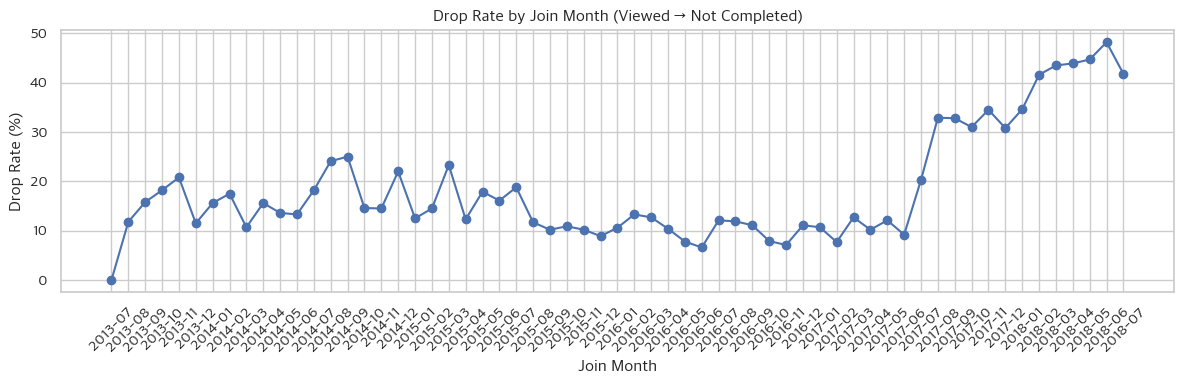

In [18]:
# Viewed 한 사람만 대상으로: completed=False 비율 = drop_rate
tmp = df[df["viewed"] == True].copy()

ym_rate = (
    tmp.groupby("join_ym")
       .agg(
           n=("id","count"),
           drop_rate=("completed", lambda x: (1 - x.mean()) * 100)
       )
       .reset_index()
)

ym_rate["drop_rate"] = ym_rate["drop_rate"].round(1)
ym_rate["join_ym_dt"] = pd.to_datetime(ym_rate["join_ym"])
ym_rate = ym_rate.sort_values("join_ym_dt")

# Plot
plt.figure(figsize=(12,4))
plt.plot(ym_rate["join_ym"], ym_rate["drop_rate"], marker="o")
plt.title("Drop Rate by Join Month (Viewed → Not Completed)")
plt.xlabel("Join Month")
plt.ylabel("Drop Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

가입 시점이 최근일수록
오퍼를 조회한 이후 완료로 이어지지 못하는 비율이 급격히 증가하며,
이는 고객 특성 변화보다는 오퍼 설계·온보딩 구조의 불일치 가능성을 시사한다.